# Ejercicio 12: Multimodal Embeddings
## Nombre: Joel Quilumba
### Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

###Paso 0 — Preparación del entorno

In [45]:
!pip -q install transformers
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from sklearn.decomposition import PCA

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

Dispositivo: cuda


### Paso 1 - Preparación de Datos
Vamos a descargar algunas imágenes de ejemplo y definir textos descriptivos para comparar sus embeddings.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

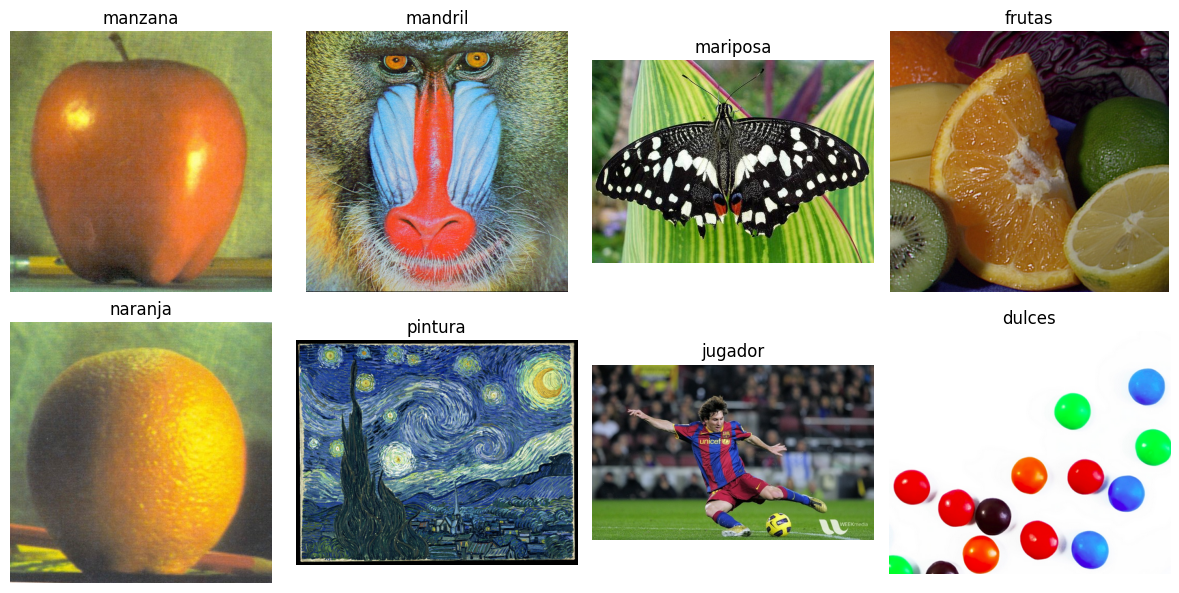

In [44]:
# cargar el modelo y el procesador
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# imágenes de ejemplo
BASE = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data"
image_urls = {
    "manzana":  f"{BASE}/apple.jpg",
    "mandril":  f"{BASE}/baboon.jpg",
    "mariposa": f"{BASE}/butterfly.jpg",
    "frutas":   f"{BASE}/fruits.jpg",
    "naranja":  f"{BASE}/orange.jpg",
    "pintura":  f"{BASE}/starry_night.jpg",
    "jugador":  f"{BASE}/messi5.jpg",
    "dulces":   f"{BASE}/smarties.png",
}

# Descripción en inglés que le pasamos a CLIP
captions = [
    "a photo of an apple",
    "a photo of a baboon",
    "a photo of a butterfly",
    "a photo of some fruits",
    "a photo of an orange",
    "a painting of a starry night",
    "a photo of a soccer player",
    "a photo of colorful candies",
]

labels = list(image_urls.keys())
images = [Image.open(BytesIO(requests.get(u).content)).convert("RGB") for u in image_urls.values()]

# Vista rápida de las imágenes cargadas
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.ravel(), images, labels):
    ax.imshow(img)
    ax.set_title(lbl)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [37]:
#Calcular los embeddings de imágenes y de textos
with torch.no_grad():
    img_inputs = processor(images=images, return_tensors="pt").to(device)
    image_embeds = model.get_image_features(**img_inputs).pooler_output

    txt_inputs = processor(text=captions, return_tensors="pt", padding=True).to(device)
    text_embeds = model.get_text_features(**txt_inputs).pooler_output

# Normalizamos a longitud 1
image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds  = text_embeds  / text_embeds.norm(dim=-1, keepdim=True)

image_embeds = image_embeds.cpu().numpy()
text_embeds  = text_embeds.cpu().numpy()
print("Embeddings calculados ")

Embeddings calculados 


###Paso 2 — Verificar que ambos viven en el mismo espacio

In [38]:
# Confirmar que imágenes y textos comparten el mismo espacio vectorial
print(f"Shape embeddings de imágenes: {image_embeds.shape} (N_imágenes, Dimensión)")
print(f"Shape embeddings de textos:   {text_embeds.shape} (N_textos, Dimensión)")
print("¿Misma dimensión?", image_embeds.shape[1] == text_embeds.shape[1])

# Ejemplo con la primera imagen del nuevo set
indice_ejemplo = 0
label_ejemplo = labels[indice_ejemplo]
texto_ejemplo = captions[indice_ejemplo]

sim_ejemplo = float(np.dot(image_embeds[indice_ejemplo], text_embeds[indice_ejemplo]))

print(f"\nEjemplo de similitud para '{label_ejemplo}':")
print(f"Imagen '{label_ejemplo}' ↔ Texto '{texto_ejemplo}': {sim_ejemplo:.3f}")

Shape embeddings de imágenes: (8, 512) (N_imágenes, Dimensión)
Shape embeddings de textos:   (8, 512) (N_textos, Dimensión)
¿Misma dimensión? True

Ejemplo de similitud para 'manzana':
Imagen 'manzana' ↔ Texto 'a photo of an apple': 0.314


###Paso 3 — Proyectar los vectores a 2D y graficarlos

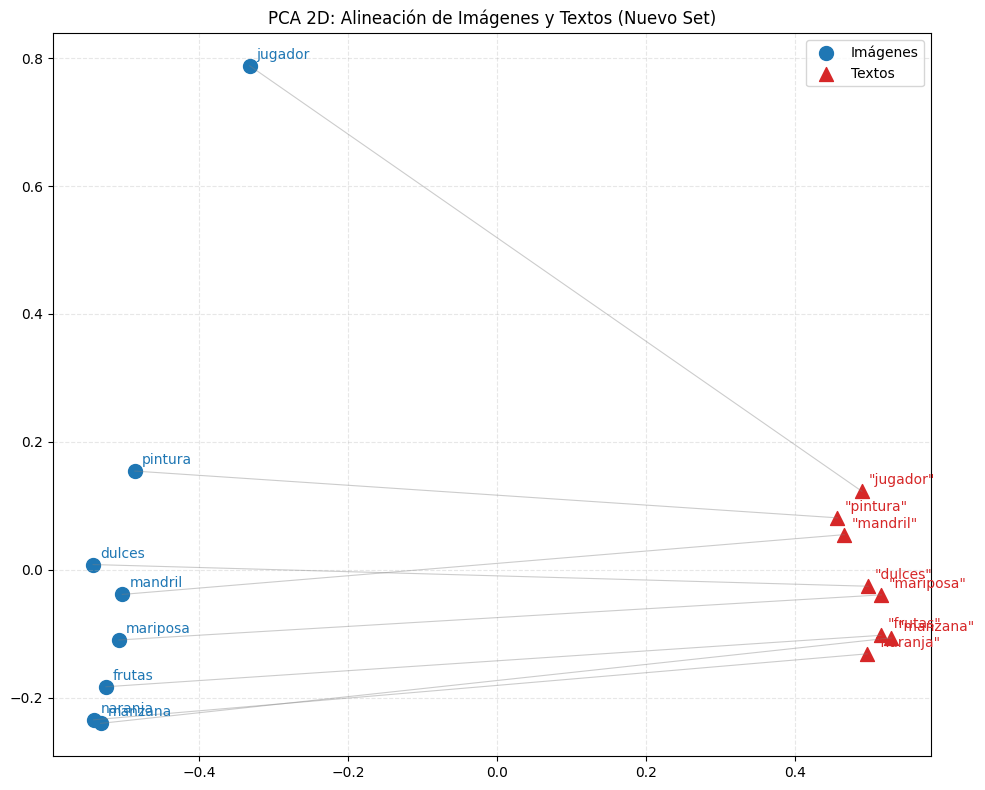

In [39]:
# Reducir a 2D con PCA y graficar el nuevo conjunto
all_embeds = np.vstack([image_embeds, text_embeds])
coords = PCA(n_components=2, random_state=42).fit_transform(all_embeds)

img_xy = coords[:len(labels)]
txt_xy = coords[len(labels):]

plt.figure(figsize=(10, 8))
plt.scatter(img_xy[:, 0], img_xy[:, 1], c="tab:blue", marker="o", s=100, label="Imágenes")
plt.scatter(txt_xy[:, 0], txt_xy[:, 1], c="tab:red", marker="^", s=100, label="Textos")

for i, lbl in enumerate(labels):
    # Etiqueta de la imagen
    plt.annotate(lbl, img_xy[i], fontsize=10, color="tab:blue",
                 xytext=(5, 5), textcoords="offset points")
    # Etiqueta del texto
    plt.annotate(f'"{lbl}"', txt_xy[i], fontsize=10, color="tab:red",
                 xytext=(5, 5), textcoords="offset points")
    # Línea que une los pares correspondientes
    plt.plot([img_xy[i, 0], txt_xy[i, 0]], [img_xy[i, 1], txt_xy[i, 1]], "gray", lw=0.8, alpha=0.4)

plt.title("PCA 2D: Alineación de Imágenes y Textos (Nuevo Set)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

###Paso 4 — Verificar emparejamientos con cosine similarity

In [42]:
#matriz de similitud coseno (filas=imágenes, columnas=textos)
sims = image_embeds @ text_embeds.T

# Búsqueda imagen -> texto
print(" IMAGEN → TEXTO")
for i, lbl in enumerate(labels):
    j = sims[i].argmax()
    ok = "Si" if j == i else "No"
    print(f"  Imagen '{lbl}'  ->  \"{captions[j]}\"  (sim={sims[i, j]:.3f}) {ok}")

# Búsqueda texto -> imagen
print("\n TEXTO → IMAGEN")
for j, cap in enumerate(captions):
    i = sims[:, j].argmax()
    ok = "si" if i == j else "no"
    print(f'  "{cap}"  ->  imagen \'{labels[i]}\'  (sim={sims[i, j]:.3f}) {ok}')

acc = np.mean(sims.argmax(axis=1) == np.arange(len(labels)))
print(f"\nExactitud del emparejamiento imagen→texto: {acc:.0%}")

 IMAGEN → TEXTO
  Imagen 'manzana'  ->  "a photo of an apple"  (sim=0.314) Si
  Imagen 'mandril'  ->  "a photo of a baboon"  (sim=0.299) Si
  Imagen 'mariposa'  ->  "a photo of a butterfly"  (sim=0.284) Si
  Imagen 'frutas'  ->  "a photo of some fruits"  (sim=0.285) Si
  Imagen 'naranja'  ->  "a photo of an orange"  (sim=0.338) Si
  Imagen 'pintura'  ->  "a painting of a starry night"  (sim=0.325) Si
  Imagen 'jugador'  ->  "a photo of a soccer player"  (sim=0.275) Si
  Imagen 'dulces'  ->  "a photo of colorful candies"  (sim=0.273) Si

 TEXTO → IMAGEN
  "a photo of an apple"  ->  imagen 'manzana'  (sim=0.314) si
  "a photo of a baboon"  ->  imagen 'mandril'  (sim=0.299) si
  "a photo of a butterfly"  ->  imagen 'mariposa'  (sim=0.284) si
  "a photo of some fruits"  ->  imagen 'frutas'  (sim=0.285) si
  "a photo of an orange"  ->  imagen 'naranja'  (sim=0.338) si
  "a painting of a starry night"  ->  imagen 'pintura'  (sim=0.325) si
  "a photo of a soccer player"  ->  imagen 'jugador' 

### Visualización de la Matriz de Similitud
Para validar el emparejamiento, graficamos la similitud coseno entre todas las combinaciones posibles. La diagonal iluminada confirma un emparejamiento perfecto.

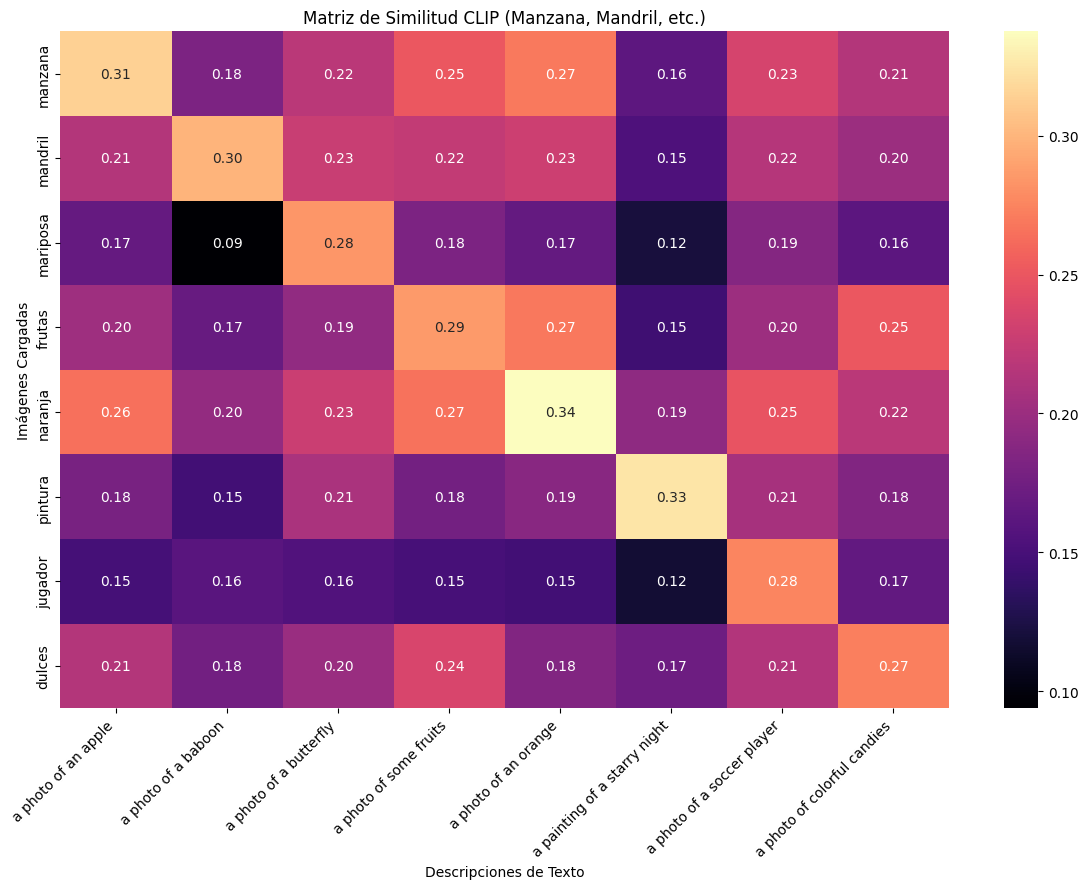

In [43]:
import seaborn as sns

# Visualizar la matriz para el nuevo set
plt.figure(figsize=(12, 9))
sns.heatmap(sims,
            xticklabels=captions,
            yticklabels=labels,
            annot=True,
            fmt=".2f",
            cmap="magma")

plt.title("Matriz de Similitud CLIP (Manzana, Mandril, etc.)")
plt.xlabel("Descripciones de Texto")
plt.ylabel("Imágenes Cargadas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()